<a href="https://colab.research.google.com/github/Aldy9814/class_BankChurn/blob/main/FInal_DSAI_Modelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Load Dataset

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/KULIAH/DSAI/Dataset/bank_churn_balanced_smote.csv')

In [ ]:
print("Ukuran dataset:", df.shape)
df.head()

Ukuran dataset: (15926, 10)


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,0,42,2,0.00,1,1,1,101348.88,1
1,608,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,39,1,0.00,2,0,0,93826.63,0
4,850,0,43,2,125510.82,1,1,1,79084.10,0


# Split Data

In [ ]:
X = df.drop('Exited', axis=1)
y = df['Exited']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training size: {X_train.shape[0]}")
print(f"Testing size: {X_test.shape[0]}")

Training size: 12740
Testing size: 3186


# Model Building

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

dt_model = DecisionTreeClassifier(max_depth=10, random_state=42)
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)

print("Training Decision Tree.")
dt_model.fit(X_train, y_train)

print("Training Random Forest.")
rf_model.fit(X_train, y_train)

print("Training done.")

Training Decision Tree.
Training Random Forest.
Training done.


# Prediksi dan Evaluasi

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

dt_pred = dt_model.predict(X_test)
rf_pred = rf_model.predict(X_test)

def tampilkan_evaluasi(nama_model, y_asli, y_prediksi):
    print(f"EVALUASI MODEL: {nama_model}")
    print(f"Accuracy  : {accuracy_score(y_asli, y_prediksi):.4f}")
    print(f"Precision : {precision_score(y_asli, y_prediksi):.4f}")
    print(f"Recall    : {recall_score(y_asli, y_prediksi):.4f}")
    print(f"F1-Score  : {f1_score(y_asli, y_prediksi):.4f}")
    print("\nDetail Classification Report:")
    print(classification_report(y_asli, y_prediksi))
    print("\n")

tampilkan_evaluasi("DECISION TREE", y_test, dt_pred)
tampilkan_evaluasi("RANDOM FOREST", y_test, rf_pred)

EVALUASI MODEL: DECISION TREE
Accuracy  : 0.7972
Precision : 0.7885
Recall    : 0.8123
F1-Score  : 0.8002

Detail Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.78      0.79      1593
           1       0.79      0.81      0.80      1593

    accuracy                           0.80      3186
   macro avg       0.80      0.80      0.80      3186
weighted avg       0.80      0.80      0.80      3186



EVALUASI MODEL: RANDOM FOREST
Accuracy  : 0.8280
Precision : 0.8317
Recall    : 0.8223
F1-Score  : 0.8270

Detail Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.83      0.83      1593
           1       0.83      0.82      0.83      1593

    accuracy                           0.83      3186
   macro avg       0.83      0.83      0.83      3186
weighted avg       0.83      0.83      0.83      3186





# Visualisasi Decision Tree

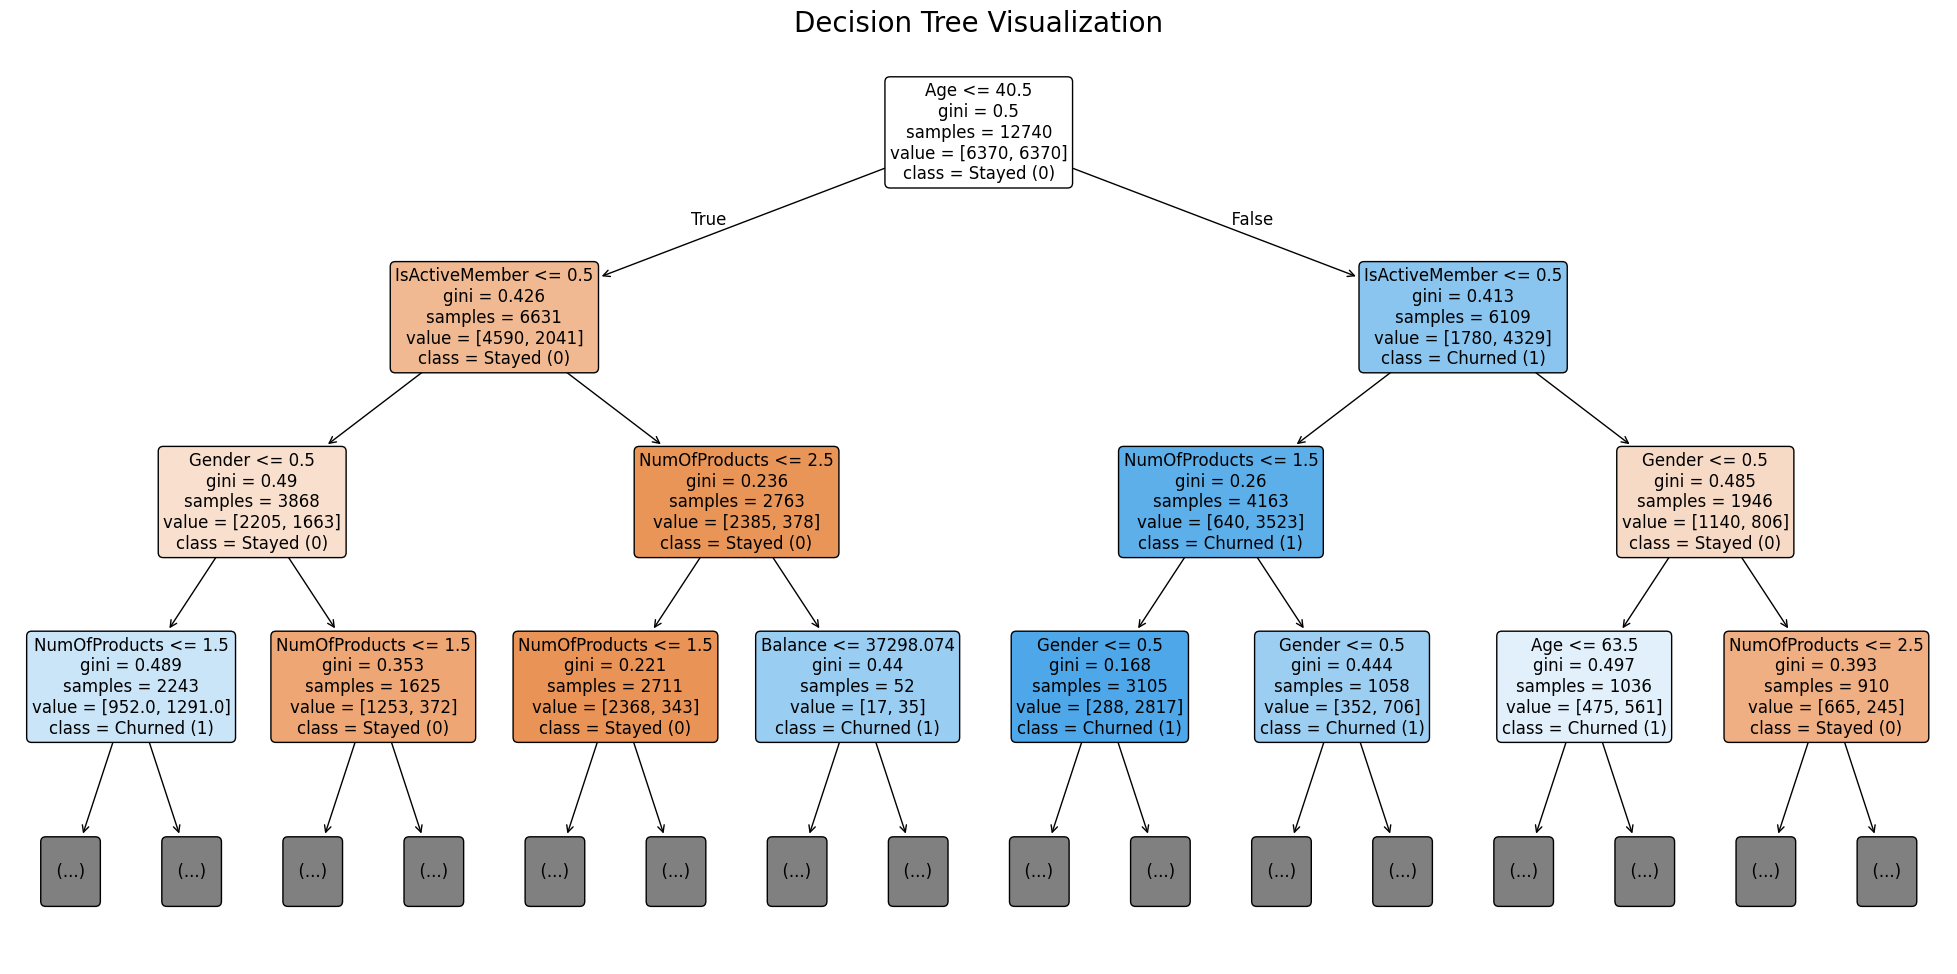

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

nama_fitur = X_train.columns.tolist()

nama_kelas = ['Stayed (0)', 'Churned (1)']

plt.figure(figsize=(25, 12))
plot_tree(dt_model,
          feature_names=nama_fitur,
          class_names=nama_kelas,
          filled=True,
          rounded=True,
          fontsize=12,
          max_depth=3)

plt.title("Decision Tree Visualization", fontsize=20)
plt.show()

# Visualisasi Random Forest

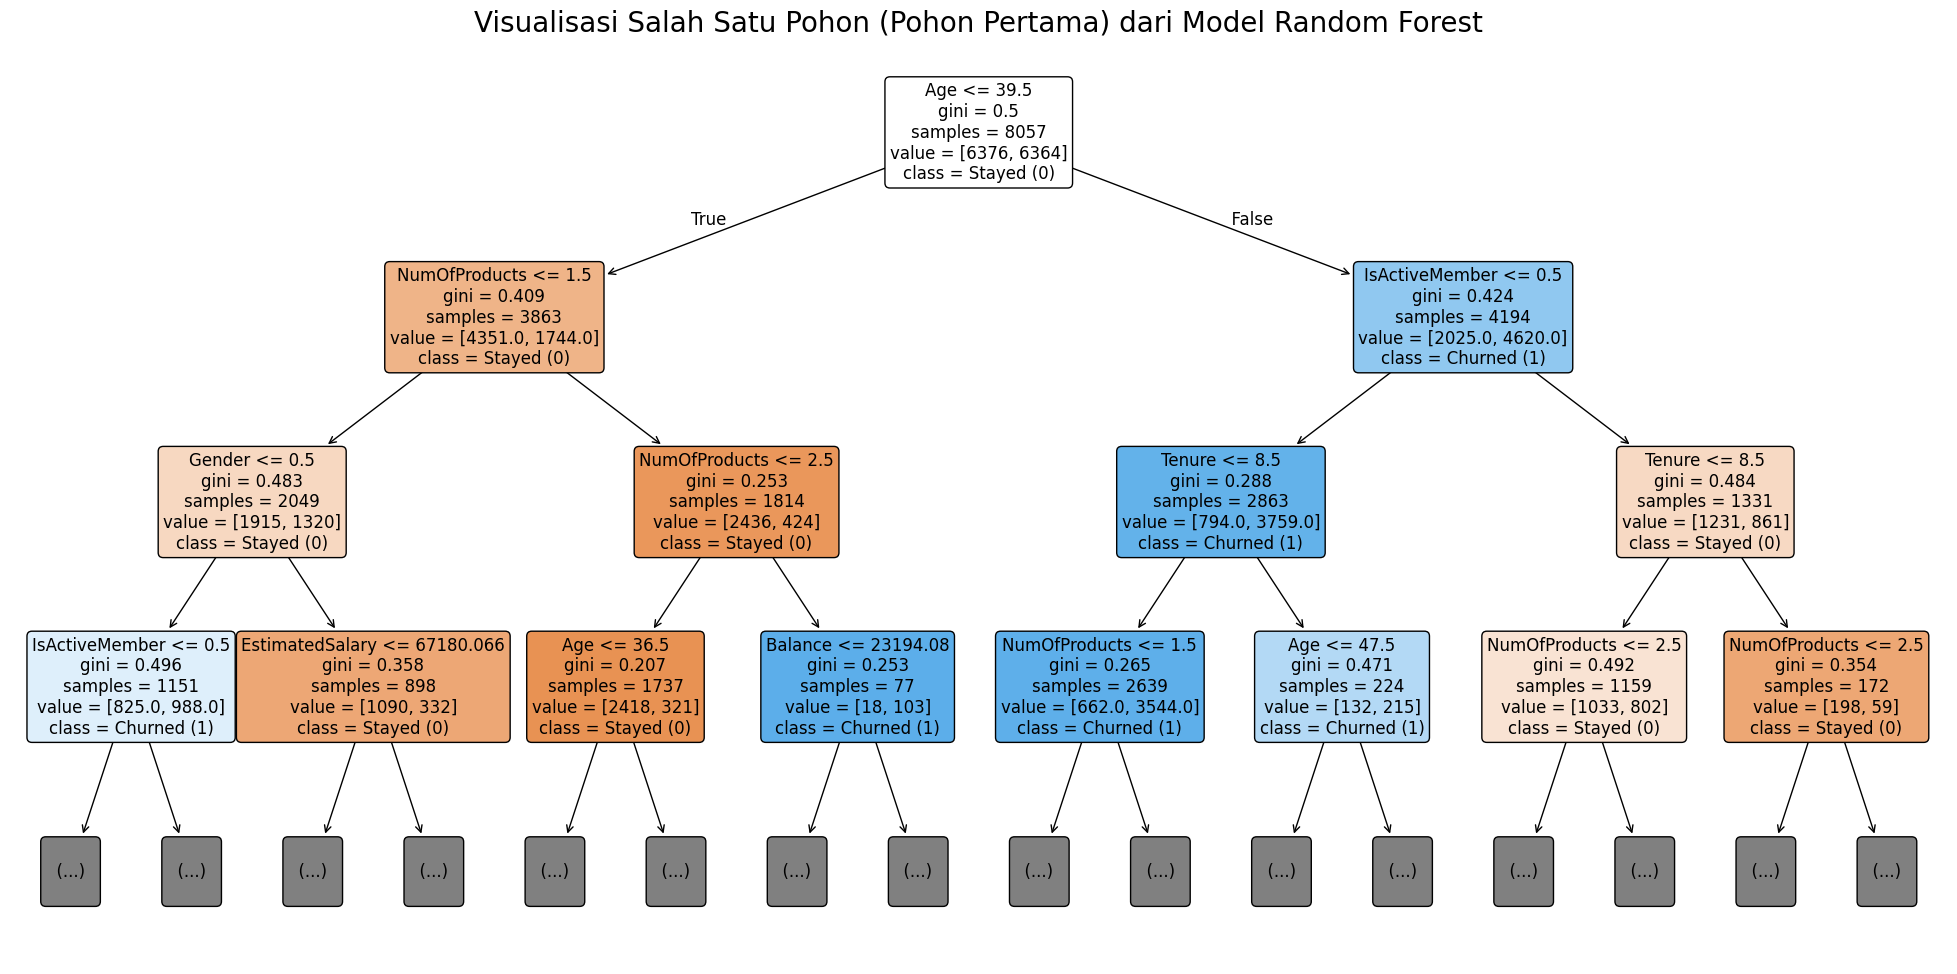

In [ ]:
pohon_pilihan = rf_model.estimators_[0]

plt.figure(figsize=(25, 12))
plot_tree(pohon_pilihan,
          feature_names=nama_fitur,
          class_names=nama_kelas,
          filled=True,
          rounded=True,
          fontsize=12,
          max_depth=3)
plt.title("Visualisasi Salah Satu Pohon (Pohon Pertama) dari Model Random Forest", fontsize=20)
plt.show()

# Confusion Matrix

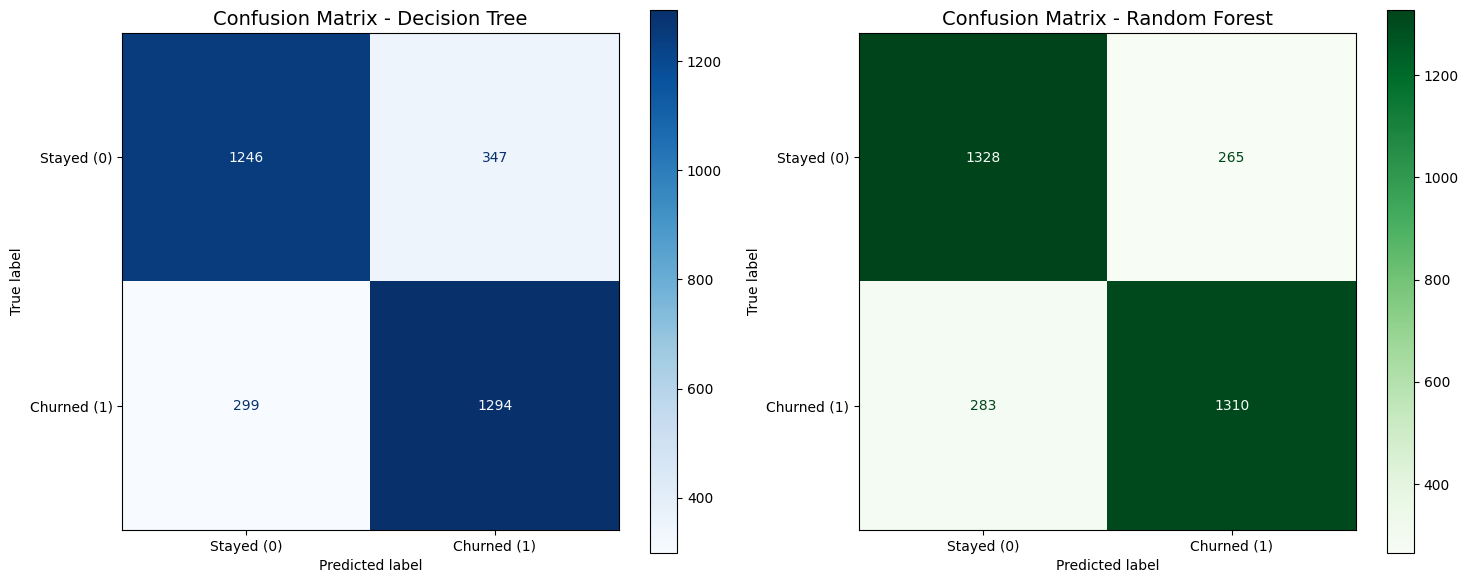

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_dt = confusion_matrix(y_test, dt_pred)
cm_rf = confusion_matrix(y_test, rf_pred)

label_kelas = ['Stayed (0)', 'Churned (1)']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=label_kelas)
disp_dt.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('Confusion Matrix - Decision Tree', fontsize=14)

disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=label_kelas)
disp_rf.plot(ax=axes[1], cmap='Greens', values_format='d')
axes[1].set_title('Confusion Matrix - Random Forest', fontsize=14)

plt.tight_layout()
plt.show()

ROC AUC

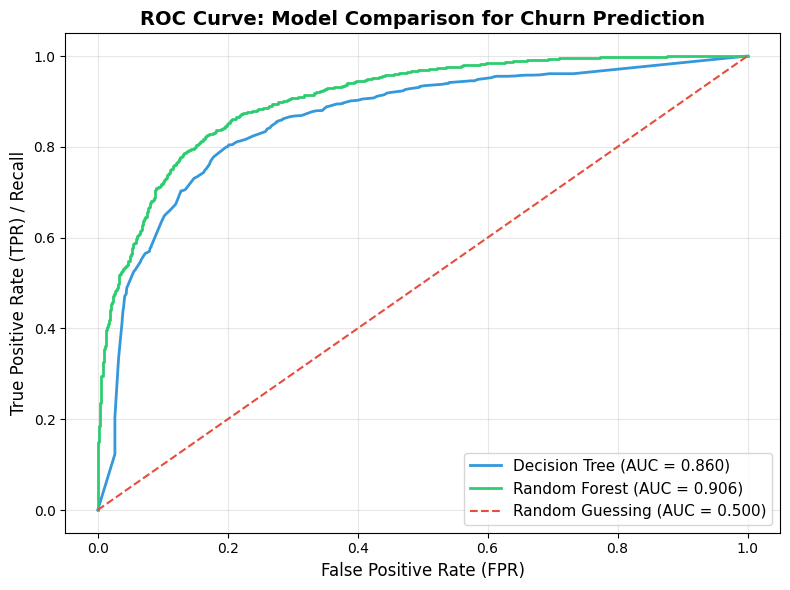

In [ ]:

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt


y_prob_dt = dt_model.predict_proba(X_test)[:, 1]
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

auc_dt = roc_auc_score(y_test, y_prob_dt)
auc_rf = roc_auc_score(y_test, y_prob_rf)

fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8, 6))

plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {auc_dt:.3f})', color='#3498db', linewidth=2)

plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})', color='#2ecc71', linewidth=2)

plt.plot([0, 1], [0, 1], color='#e74c3c', linestyle='--', label='Random Guessing (AUC = 0.500)')

plt.title('ROC Curve: Model Comparison for Churn Prediction', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR) / Recall', fontsize=12)
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

# SHAP

In [ ]:
!pip install shap

SHAP


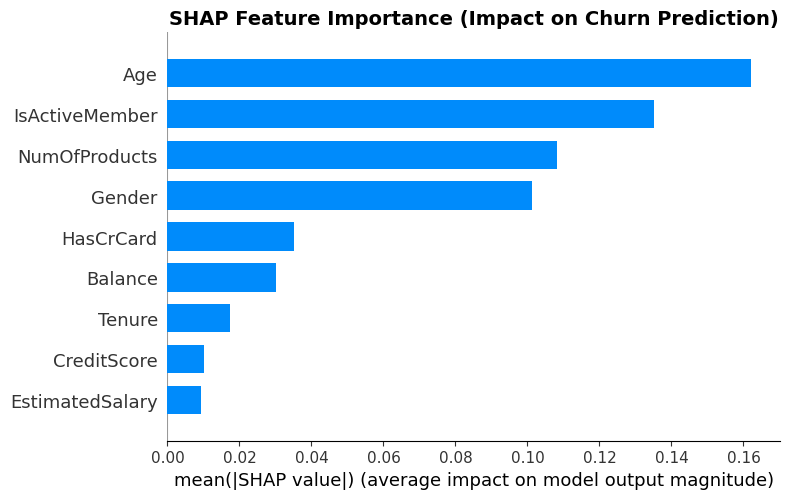

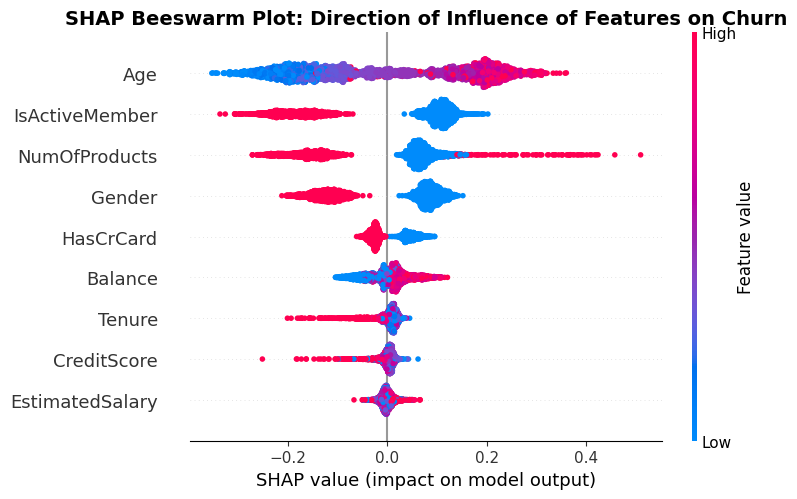

In [ ]:
import shap

shap.initjs()

print("SHAP")

explainer = shap.TreeExplainer(rf_model)

shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 6))
plt.title('SHAP Feature Importance (Impact on Churn Prediction)', fontsize=14, fontweight='bold')

shap.summary_plot(shap_values[:, :, 1], X_test, plot_type="bar", show=False)
plt.show()

plt.figure(figsize=(10, 6))
plt.title('SHAP Beeswarm Plot: Direction of Influence of Features on Churn', fontsize=14, fontweight='bold')
shap.summary_plot(shap_values[:, :, 1], X_test, show=False)
plt.show()

In [ ]:
train_accuracy = rf_model.score(X_train, y_train)

test_accuracy = rf_model.score(X_test, y_test)

print(f"Train Accuracy : {train_accuracy * 100:.2f}%")
print(f"Testing Accuracy: {test_accuracy * 100:.2f}%")

if train_accuracy > test_accuracy + 0.10:
    print("Status: OVERFITTING")
elif train_accuracy < 0.65 and test_accuracy < 0.65:
    print("Status: UNDERFITTING")
else:
    print("Status: GOOD FIT")

Train Accuracy : 88.29%
Testing Accuracy: 82.80%
Status: GOOD FIT
